# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Zico Diego Rio Ramadhonny | 5054251023 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import (
    CategoricalNB,
    BernoulliNB,
    MultinomialNB,
)
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)


In [3]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

path = kagglehub.dataset_download("uciml/mushroom-classification")
print("Path to dataset files:", path)

dataset_file = None
files_in_path = [os.path.join(path, file) for file in os.listdir(path)]
for file in files_in_path:
    if os.path.isfile(file) and os.path.splitext(os.path.basename(file))[-1] == ".csv":
        dataset_file = file
        break
    
if dataset_file is None:
    raise FileNotFoundError(f"CSV dataset file can't be found at {path}.")

#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv(dataset_file)

# MAPPING AGAR NAMA FITUR LEBIH MUDAH DIBACA.
mushroom_features = {
    "cap-shape": {
        "b": "bell",
        "c": "conical",
        "x": "convex",
        "f": "flat",
        "k": "knobbed",
        "s": "sunken"
    },
    "cap-surface": {
        "f": "fibrous",
        "g": "grooves",
        "y": "scaly",
        "s": "smooth"
    },
    "cap-color": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "r": "green",
        "p": "pink",
        "u": "purple",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "bruises": {
        "t": "bruises",
        "f": "no"
    },
    "odor": {
        "a": "almond",
        "l": "anise",
        "c": "creosote",
        "y": "fishy",
        "f": "foul",
        "m": "musty",
        "n": "none",
        "p": "pungent",
        "s": "spicy"
    },
    "gill-attachment": {
        "a": "attached",
        "d": "descending",
        "f": "free",
        "n": "notched"
    },
    "gill-spacing": {
        "c": "close",
        "w": "crowded",
        "d": "distant"
    },
    "gill-size": {
        "b": "broad",
        "n": "narrow"
    },
    "gill-color": {
        "k": "black",
        "n": "brown",
        "b": "buff",
        "h": "chocolate",
        "g": "gray",
        "r": "green",
        "o": "orange",
        "p": "pink",
        "u": "purple",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "stalk-shape": {
        "e": "enlarging",
        "t": "tapering"
    },
    "stalk-root": {
        "b": "bulbous",
        "c": "club",
        "u": "cup",
        "e": "equal",
        "z": "rhizomorphs",
        "r": "rooted",
        "?": None
    },
    "stalk-surface-above-ring": {
        "f": "fibrous",
        "y": "scaly",
        "k": "silky",
        "s": "smooth"
    },
    "stalk-surface-below-ring": {
        "f": "fibrous",
        "y": "scaly",
        "k": "silky",
        "s": "smooth"
    },
    "stalk-color-above-ring": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "o": "orange",
        "p": "pink",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "stalk-color-below-ring": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "o": "orange",
        "p": "pink",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "veil-type": {
        "p": "partial",
        "u": "universal"
    },
    "veil-color": {
        "n": "brown",
        "o": "orange",
        "w": "white",
        "y": "yellow"
    },
    "ring-number": {
        "n": "none",
        "o": "one",
        "t": "two"
    },
    "ring-type": {
        "c": "cobwebby",
        "e": "evanescent",
        "f": "flaring",
        "l": "large",
        "n": "none",
        "p": "pendant",
        "s": "sheathing",
        "z": "zone"
    },
    "spore-print-color": {
        "k": "black",
        "n": "brown",
        "b": "buff",
        "h": "chocolate",
        "r": "green",
        "o": "orange",
        "u": "purple",
        "w": "white",
        "y": "yellow"
    },
    "population": {
        "a": "abundant",
        "c": "clustered",
        "n": "numerous",
        "s": "scattered",
        "v": "several",
        "y": "solitary"
    },
    "habitat": {
        "g": "grasses",
        "l": "leaves",
        "m": "meadows",
        "p": "paths",
        "u": "urban",
        "w": "waste",
        "d": "woods"
    },
    "class": {
        "e": "Edible", 
        "p": "Poisonous"
    }
}

for key, map_val in mushroom_features.items():
    data[key] = data[key].map(map_val)

print("Dataset info:")
print(data.info())

print("Dataset head:")
data.head()

Path to dataset files: /home/zico/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1
Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                5644 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,Poisonous,convex,smooth,brown,bruises,pungent,free,close,narrow,black,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
1,Edible,convex,smooth,yellow,bruises,almond,free,close,broad,black,...,smooth,white,white,partial,white,one,pendant,brown,numerous,grasses
2,Edible,bell,smooth,white,bruises,anise,free,close,broad,brown,...,smooth,white,white,partial,white,one,pendant,brown,numerous,meadows
3,Poisonous,convex,scaly,white,bruises,pungent,free,close,narrow,brown,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
4,Edible,convex,smooth,gray,no,none,free,crowded,broad,black,...,smooth,white,white,partial,white,one,evanescent,brown,abundant,grasses


In [4]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

for col in mushroom_features.keys():
    nan_mask     = data[col].isna()
    flatten_mask = nan_mask.loc[nan_mask]
    n_nan_count  = len(flatten_mask)
    
    if n_nan_count:
        print(f"Missing value count for {col} column: {len(flatten_mask)}")
        nan_rows = data.loc[nan_mask]
        mode     = data[col].mode()
        
        poison_nan_count = len(nan_rows[nan_rows["class"] == "Poisonous"])
        edible_nan_count = len(nan_rows[nan_rows["class"] == "Edible"])
        
        print("\nMissing value count for 'Poisonous' class:", poison_nan_count)
        print("Missing value count for 'Edible' class:", edible_nan_count)
        print(f"Mode for {col} column:", mode.values[0])

Missing value count for stalk-root column: 2480

Missing value count for 'Poisonous' class: 1760
Missing value count for 'Edible' class: 720
Mode for stalk-root column: bulbous


In [5]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

print("Unique values for each column:")
for col in mushroom_features.keys():
    unique_val = list(data[col].unique())
    
    print(f"- {col}:", unique_val, f"({len(unique_val)})")
    
data = data.drop(columns=["veil-type"])

Unique values for each column:
- cap-shape: ['convex', 'bell', 'sunken', 'flat', 'knobbed', 'conical'] (6)
- cap-surface: ['smooth', 'scaly', 'fibrous', 'grooves'] (4)
- cap-color: ['brown', 'yellow', 'white', 'gray', 'red', 'pink', 'buff', 'purple', 'cinnamon', 'green'] (10)
- bruises: ['bruises', 'no'] (2)
- odor: ['pungent', 'almond', 'anise', 'none', 'foul', 'creosote', 'fishy', 'spicy', 'musty'] (9)
- gill-attachment: ['free', 'attached'] (2)
- gill-spacing: ['close', 'crowded'] (2)
- gill-size: ['narrow', 'broad'] (2)
- gill-color: ['black', 'brown', 'gray', 'pink', 'white', 'chocolate', 'purple', 'red', 'buff', 'green', 'yellow', 'orange'] (12)
- stalk-shape: ['enlarging', 'tapering'] (2)
- stalk-root: ['equal', 'club', 'bulbous', 'rooted', nan] (5)
- stalk-surface-above-ring: ['smooth', 'fibrous', 'silky', 'scaly'] (4)
- stalk-surface-below-ring: ['smooth', 'fibrous', 'scaly', 'silky'] (4)
- stalk-color-above-ring: ['white', 'gray', 'pink', 'brown', 'buff', 'red', 'orange', 'ci

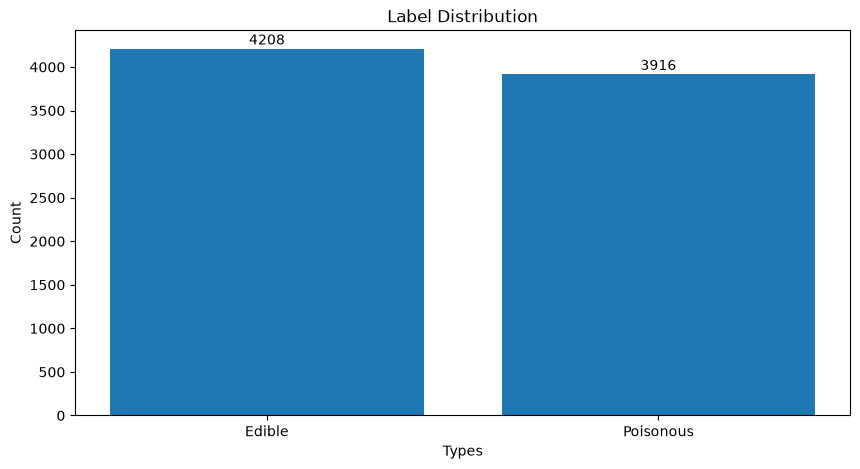

In [6]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

label_count = data["class"].value_counts()

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 5))

ax.bar(label_count.keys(), label_count.values, align="center")
ax.set_title("Label Distribution")
ax.set_xlabel("Types")
ax.set_ylabel("Count")
for key, val in label_count.items():
    ax.text(key, val+50, str(val), ha="center")

plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [7]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

# WITH IMPUTE
impute_data        = data.copy()
missing_impute_col = impute_data["stalk-root"]
mode_impute_col    = missing_impute_col.mode().values[0]

missing_impute_col[missing_impute_col.isna()] = mode_impute_col
impute_data["stalk-root"]                     = missing_impute_col

# WITH DROP
drop_data = data.copy()[~data.isna().any(axis=1)]

# AS NEW CATEGORY
new_cat_data                                                      = data.copy()
new_cat_data.loc[new_cat_data["stalk-root"].isna(), "stalk-root"] = "?"

In [8]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

# Sudah di atas.

In [9]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.


def split_dataset(df):
    X = df.drop(columns=["class"])
    y = df["class"].map({"Edible": 0, "Poisonous": 1})
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


impute_X_train, impute_X_test, impute_y_train, impute_y_test = split_dataset(impute_data)
drop_X_train, drop_X_test, drop_y_train, drop_y_test = split_dataset(drop_data)
new_cat_X_train, new_cat_X_test, new_cat_y_train, new_cat_y_test = split_dataset(new_cat_data)

print("Impute data shape:", impute_data.shape)
print("Drop data shape:", drop_data.shape)
print("New category data shape:", new_cat_data.shape)
print("\nClass distribution in train set (impute):")
print(impute_y_train.value_counts(normalize=True).sort_index())


Impute data shape: (8124, 22)
Drop data shape: (5644, 22)
New category data shape: (8124, 22)

Class distribution in train set (impute):
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64


In [10]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.


def encode_categorical(X_train, X_test):
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train_enc = encoder.fit_transform(X_train)
    X_test_enc = encoder.transform(X_test)
    return X_train_enc, X_test_enc


impute_cat_X_train, impute_cat_X_test = encode_categorical(impute_X_train, impute_X_test)
drop_cat_X_train, drop_cat_X_test = encode_categorical(drop_X_train, drop_X_test)
new_cat_cat_X_train, new_cat_cat_X_test = encode_categorical(new_cat_X_train, new_cat_X_test)

print("OrdinalEncoder done for all dataset variants.")


OrdinalEncoder done for all dataset variants.


In [11]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.


def encode_onehot(X_train, X_test):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_train_enc = encoder.fit_transform(X_train)
    X_test_enc = encoder.transform(X_test)
    return X_train_enc, X_test_enc


impute_oh_X_train, impute_oh_X_test = encode_onehot(impute_X_train, impute_X_test)
drop_oh_X_train, drop_oh_X_test = encode_onehot(drop_X_train, drop_X_test)
new_cat_oh_X_train, new_cat_oh_X_test = encode_onehot(new_cat_X_train, new_cat_X_test)

print("OneHotEncoder done for all dataset variants.")


OneHotEncoder done for all dataset variants.


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [12]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

cat_results = {}
for name, X_train, X_test, y_train, y_test in [
    ("With imputing", impute_cat_X_train, impute_cat_X_test, impute_y_train, impute_y_test),
    ("With dropping", drop_cat_X_train, drop_cat_X_test, drop_y_train, drop_y_test),
    ("As a new category", new_cat_cat_X_train, new_cat_cat_X_test, new_cat_y_train, new_cat_y_test),
]:
    model = CategoricalNB()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    cat_results[name] = {
        "y_true": y_test,
        "y_pred": pred,
        "y_proba": proba,
    }

print("CategoricalNB trained for all dataset variants.")


CategoricalNB trained for all dataset variants.


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

for name, result in cat_results.items():
    print(f"\n{name} - CategoricalNB")
    print(classification_report(result["y_true"], result["y_pred"], target_names=["Edible", "Poisonous"]))
    print("Accuracy:", accuracy_score(result["y_true"], result["y_pred"]), "\n")



With imputing - CategoricalNB
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Accuracy: 0.947076923076923 


With dropping - CategoricalNB
              precision    recall  f1-score   support

      Edible       0.96      1.00      0.98       698
   Poisonous       1.00      0.93      0.96       431

    accuracy                           0.97      1129
   macro avg       0.98      0.96      0.97      1129
weighted avg       0.97      0.97      0.97      1129

Accuracy: 0.970770593445527 


As a new category - CategoricalNB
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy             

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [14]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

bernoulli_results = {}
for name, X_train, X_test, y_train, y_test in [
    ("With imputing", impute_oh_X_train, impute_oh_X_test, impute_y_train, impute_y_test),
    ("With dropping", drop_oh_X_train, drop_oh_X_test, drop_y_train, drop_y_test),
    ("As a new category", new_cat_oh_X_train, new_cat_oh_X_test, new_cat_y_train, new_cat_y_test),
]:
    model = BernoulliNB()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    bernoulli_results[name] = {
        "y_true": y_test,
        "y_pred": pred,
        "y_proba": proba,
    }

print("BernoulliNB trained for all dataset variants.")


BernoulliNB trained for all dataset variants.


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

for name, result in bernoulli_results.items():
    print(f"\n{name} - BernoulliNB")
    print(classification_report(result["y_true"], result["y_pred"], target_names=["Edible", "Poisonous"]))
    print("Accuracy:", accuracy_score(result["y_true"], result["y_pred"]), "\n")



With imputing - BernoulliNB
              precision    recall  f1-score   support

      Edible       0.90      0.99      0.94       842
   Poisonous       0.98      0.88      0.93       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.94      0.93      0.93      1625

Accuracy: 0.9335384615384615 


With dropping - BernoulliNB
              precision    recall  f1-score   support

      Edible       0.92      1.00      0.95       698
   Poisonous       0.99      0.85      0.92       431

    accuracy                           0.94      1129
   macro avg       0.95      0.92      0.94      1129
weighted avg       0.95      0.94      0.94      1129

Accuracy: 0.941541186891054 


As a new category - BernoulliNB
              precision    recall  f1-score   support

      Edible       0.90      0.98      0.94       842
   Poisonous       0.98      0.88      0.93       783

    accuracy                  

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [16]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

multinomial_results = {}
for name, X_train, X_test, y_train, y_test in [
    ("With imputing", impute_oh_X_train, impute_oh_X_test, impute_y_train, impute_y_test),
    ("With dropping", drop_oh_X_train, drop_oh_X_test, drop_y_train, drop_y_test),
    ("As a new category", new_cat_oh_X_train, new_cat_oh_X_test, new_cat_y_train, new_cat_y_test),
]:
    model = MultinomialNB()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    multinomial_results[name] = {
        "y_true": y_test,
        "y_pred": pred,
        "y_proba": proba,
    }

print("MultinomialNB trained for all dataset variants.")


MultinomialNB trained for all dataset variants.


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

for name, result in multinomial_results.items():
    print(f"\n{name} - MultinomialNB")
    print(classification_report(result["y_true"], result["y_pred"], target_names=["Edible", "Poisonous"]))
    print("Accuracy:", accuracy_score(result["y_true"], result["y_pred"]), "\n")



With imputing - MultinomialNB
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Accuracy: 0.947076923076923 


With dropping - MultinomialNB
              precision    recall  f1-score   support

      Edible       0.96      1.00      0.98       698
   Poisonous       1.00      0.93      0.96       431

    accuracy                           0.97      1129
   macro avg       0.98      0.96      0.97      1129
weighted avg       0.97      0.97      0.97      1129

Accuracy: 0.970770593445527 


As a new category - MultinomialNB
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy             

# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    "CategoricalNB": cat_results,
    "BernoulliNB": bernoulli_results,
    "MultinomialNB": multinomial_results,
}

summary_rows = []
for model_name, model_results in results.items():
    for data_name, result in model_results.items():
        y_true = result["y_true"]
        y_pred = result["y_pred"]
        summary_rows.append({
            "Model": model_name,
            "Dataset": data_name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_true, result["y_proba"]),
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values(["Model", "Dataset"]).reset_index(drop=True))


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,AUC
0,BernoulliNB,As a new category,0.932923,0.981429,0.877395,0.926500,0.995428
1,BernoulliNB,With dropping,0.941541,0.991914,0.853828,0.917706,0.998508
2,BernoulliNB,With imputing,0.933538,0.982833,0.877395,0.927126,0.995516
3,CategoricalNB,As a new category,0.945846,0.990127,0.896552,0.941019,0.997185
4,CategoricalNB,With dropping,0.970771,0.995025,0.928074,0.960384,0.999312
5,CategoricalNB,With imputing,0.947077,0.988780,0.900383,0.942513,0.997402
6,MultinomialNB,As a new category,0.945846,0.990127,0.896552,0.941019,0.997185
7,MultinomialNB,With dropping,0.970771,0.995025,0.928074,0.960384,0.999312
8,MultinomialNB,With imputing,0.947077,0.988780,0.900383,0.942513,0.997402


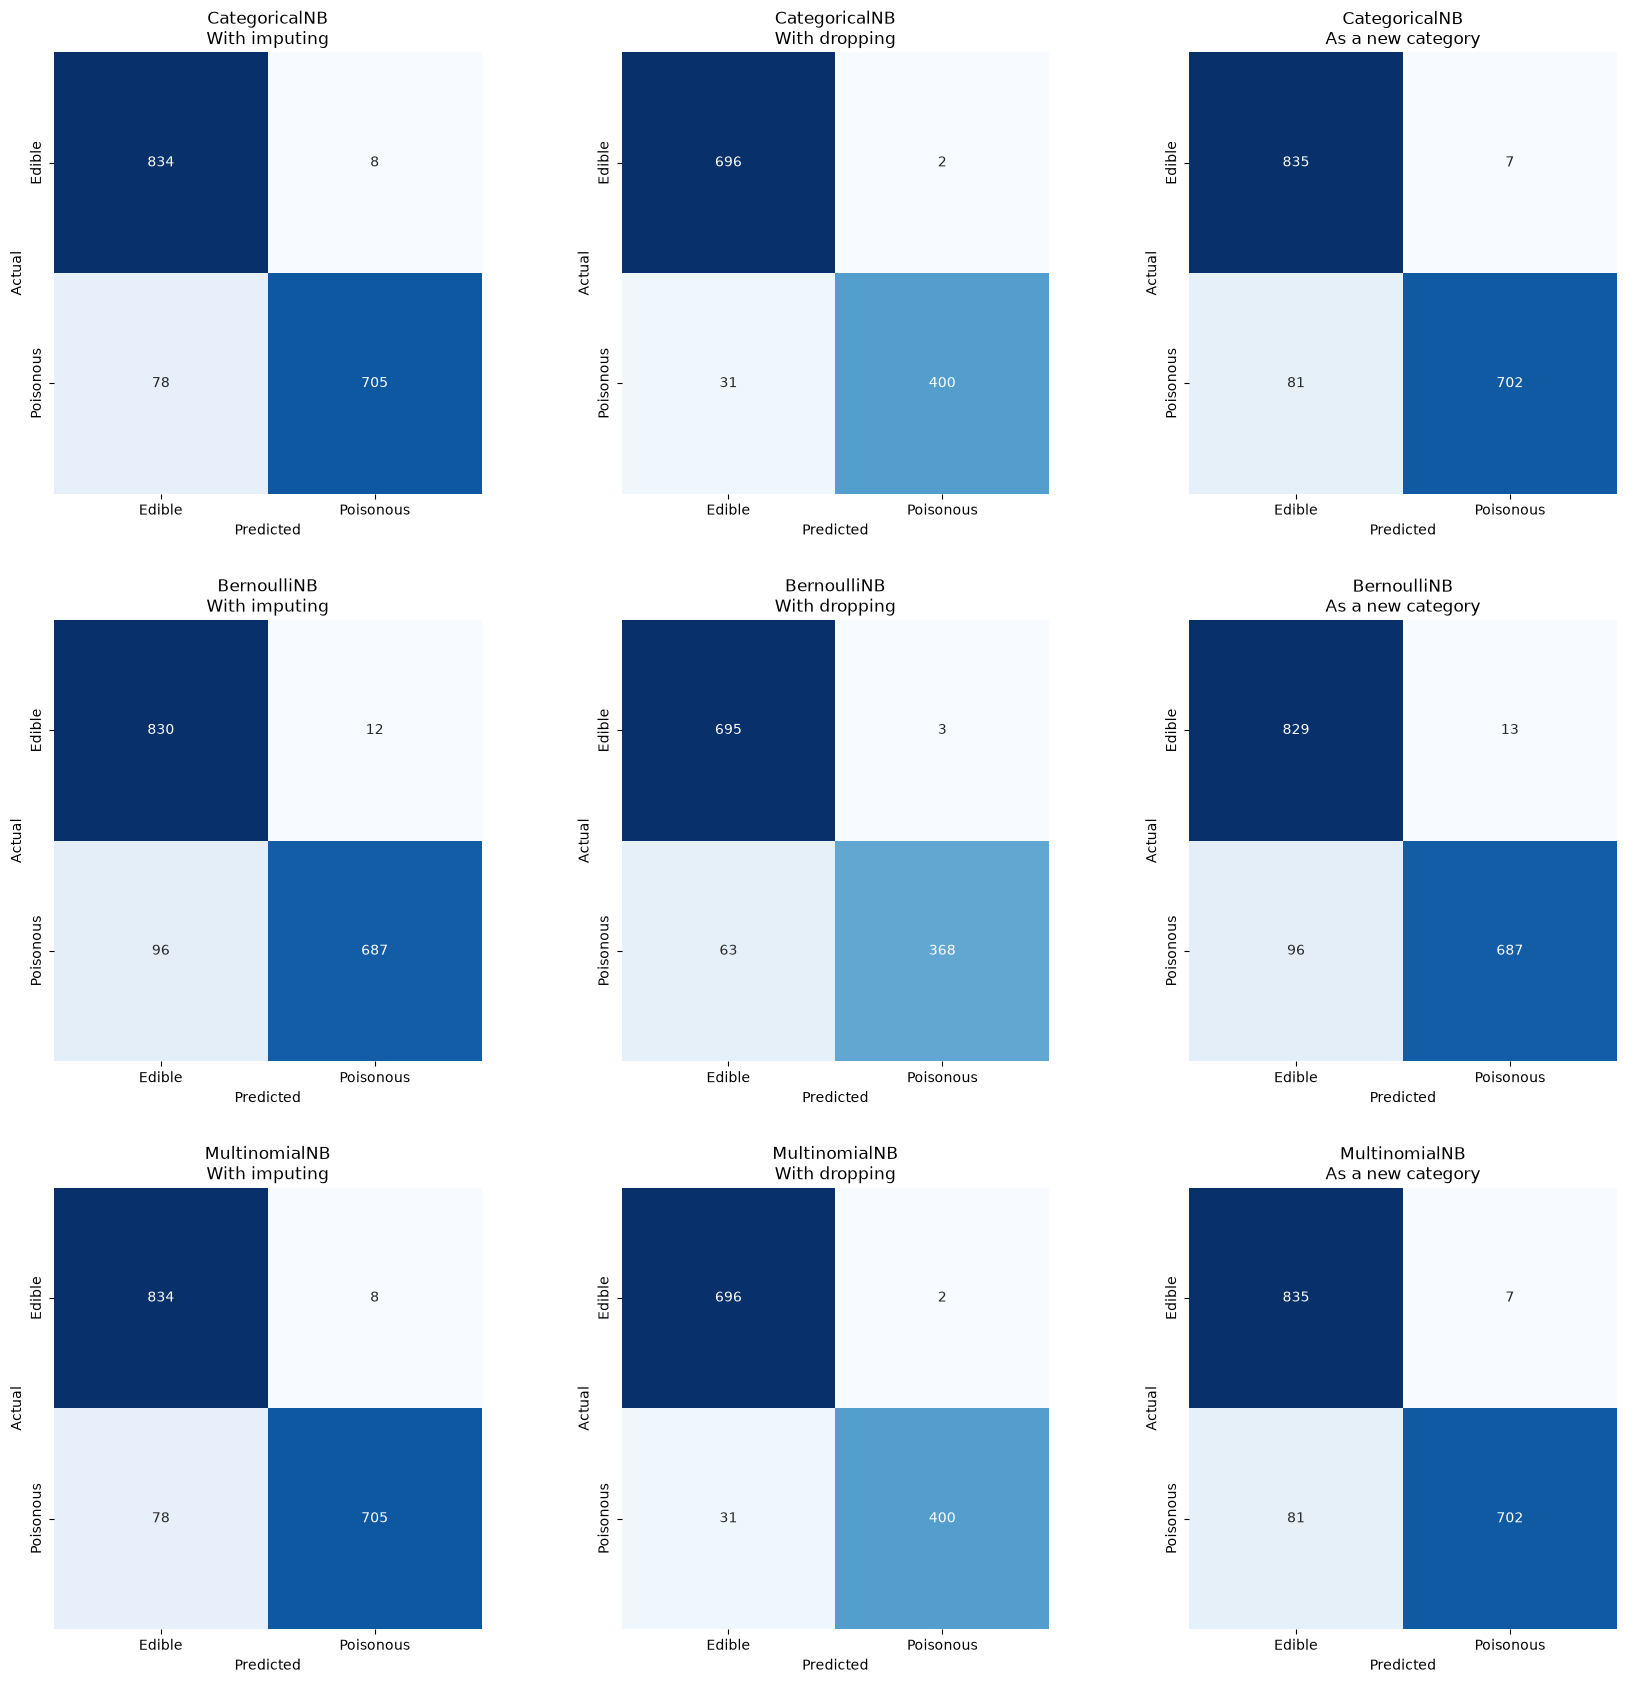

In [19]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.tight_layout(pad=7)

model_map = {
    "CategoricalNB": cat_results,
    "BernoulliNB": bernoulli_results,
    "MultinomialNB": multinomial_results,
}

for i, model_name in enumerate(model_map.keys()):
    for j, data_name in enumerate(["With imputing", "With dropping", "As a new category"]):
        y_true = model_map[model_name][data_name]["y_true"]
        y_pred = model_map[model_name][data_name]["y_pred"]
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["Edible", "Poisonous"], yticklabels=["Edible", "Poisonous"],
                    ax=axes[i, j])
        axes[i, j].set_title(f"{model_name}\n{data_name}")
        axes[i, j].set_xlabel("Predicted")
        axes[i, j].set_ylabel("Actual")

plt.show()


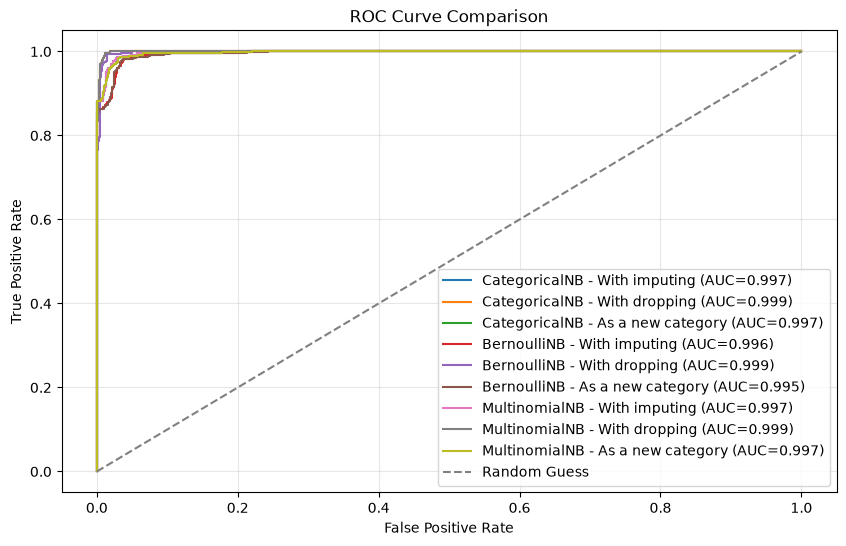

In [20]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(10, 6))
for model_name, model_results in results.items():
    for data_name in ["With imputing", "With dropping", "As a new category"]:
        y_true = model_results[data_name]["y_true"]
        y_score = model_results[data_name]["y_proba"]
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        plt.plot(fpr, tpr, label=f"{model_name} - {data_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


# 5. Analisis

Menghilangkan baris yang memiliki missing value menghasilkan akurasi, precision, dan AUC yang paling tinggi dibandingkan menambahkan nilai modus maupun membuat kategori baru, dengan beberapa variasi pada metrik recall dan F1-score pada semua model. Model CategoricalNB dan MultinomialNB menghasilkan akurasi yang sama, sedangkan model BernoulliNB menghasilkan akurasi yang terburuk di antara ketiga model.

# 6. Kesimpulan dan Saran

Kesimpulan:
Ketiga model menghasilkan skor yang baik di semua metrik, menunjukkan bahwa asumsi independensi pada algoritma Naïve Bayes bekerja dengan baik pada dataset ini.

Saran:
Tidak ada waktu istirahat dari praktikum, kah?😭